# Porfolio part 4 - Medical insurance charge data

**Introduction:**

In today's society, the prevalence of extreme poverty and starvation has significantly decreased, elevating the average living standards to unprecedented levels. As a result, people are increasingly seeking to extend their lifespans and enhance their quality of life. This desire has led to a heightened demand for medical treatment, the costs of which can vary dramatically from person to person. These costs are influenced by a myriad of factors, including age, gender, lifestyle choices, and more.

In this portfolio, I will explore the relationship between various determinants and the cost of medical treatment. The objective is to identify which factors most significantly impact healthcare expenses, thereby providing insights that could help individuals manage their medical costs more effectively. Through this analysis, I aim to contribute to the broader understanding of how demographic and health-related variables influence medical insurance charges in contemporary society.



**About the data:** The data contain insurance charges information of US citizen with several factors that might affect the medical cost


|Column|Meaning|
|:-----:|:-----:|
|age|Age of primary beneficiary|
|sex|Insurance contractor gender, female, male|
|bmi|Body mass index, providing an understanding of body, weights that are relatively high or low relative to height, objective index of body weight (kg / m ^ 2) using the ratio of height to weight, ideally 18.5 to 24.9|
|children|Number of children covered by health insurance / Number of dependents|
|smoker|Smoking|
|region|The beneficiary's residential area in the US, northeast, southeast, southwest, northwest.|
|charges|Individual medical costs billed by health insurance|


**Importing data file and libraries:**

In [160]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn import metrics
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

import matplotlib.pyplot as plt # Visualization
import seaborn as sns #Visualization

import warnings#removes warning
warnings.filterwarnings('ignore')



%matplotlib inline

df = pd.read_csv("insurance.csv")

**1. Data exporation and preparation**


***Data cleaning***

In [161]:
#using head and info 
df_head = df.head()
df_info = df.info()
df_head, df_info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


(   age     sex     bmi  children smoker     region      charges
 0   19  female  27.900         0    yes  southwest  16884.92400
 1   18    male  33.770         1     no  southeast   1725.55230
 2   28    male  33.000         3     no  southeast   4449.46200
 3   33    male  22.705         0     no  northwest  21984.47061
 4   32    male  28.880         0     no  northwest   3866.85520,
 None)

In [162]:
#Checking for missing data
print('Sum of null data in each column')
print(df.isnull().sum())
#looks like this data has no null value. Great news!
#type of data in each column is also suitable for modeling.


Sum of null data in each column
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


***Exploratory data analysis***


In [163]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


<Figure size 640x480 with 0 Axes>

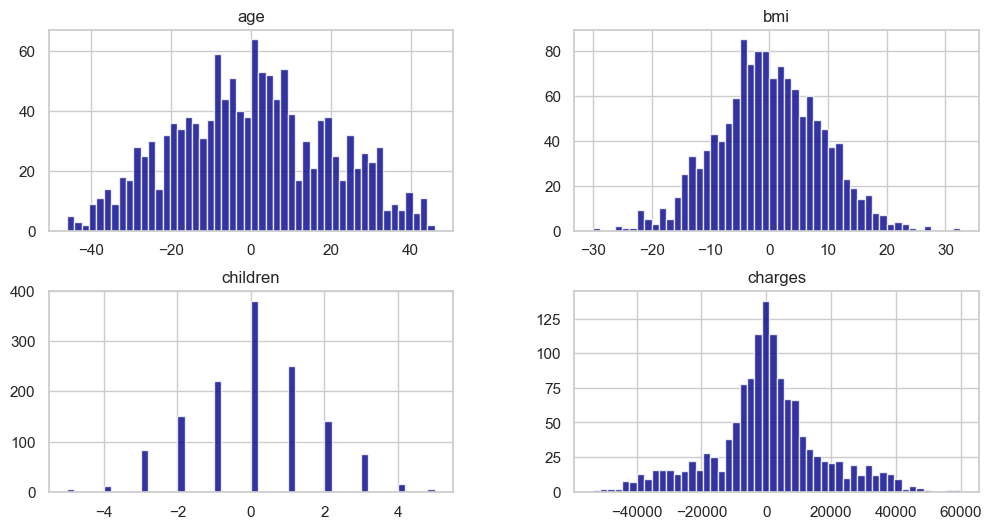

In [164]:
#Data distribution - check for distribution of data and look for outlier

plt.figure();

df[['age', 'bmi', 'children', 'charges']].diff().hist(color="darkblue", alpha=0.8, bins=50, figsize=(12, 6));



All data look like normally distributed. Now let's study about the correlation

***Studying correlation***

In [149]:
categorical = ['smoker', 'sex', 'region']
encoder = OrdinalEncoder()

# Encoding the categorical features
df_encoded = df.copy()
df_encoded[categorical] = encoder.fit_transform(df[categorical])
df_encoded.info()

correlations = df_encoded.corr()

correlations

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   float64
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   float64
 5   region    1338 non-null   float64
 6   charges   1338 non-null   float64
dtypes: float64(5), int64(2)
memory usage: 73.3 KB


,age,sex,bmi,children,smoker,region,charges
age,1.000000,-0.020856,0.109272,0.042469,-0.025019,0.002127,0.299008
sex,-0.020856,1.000000,0.046371,0.017163,0.076185,0.004588,0.057292
bmi,0.109272,0.046371,1.000000,0.012759,0.003750,0.157566,0.198341
children,0.042469,0.017163,0.012759,1.000000,0.007673,0.016569,0.067998
smoker,-0.025019,0.076185,0.003750,0.007673,1.000000,-0.002181,0.787251
region,0.002127,0.004588,0.157566,0.016569,-0.002181,1.000000,-0.006208
charges,0.299008,0.057292,0.198341,0.067998,0.787251,-0.006208,1.000000


<Axes: >

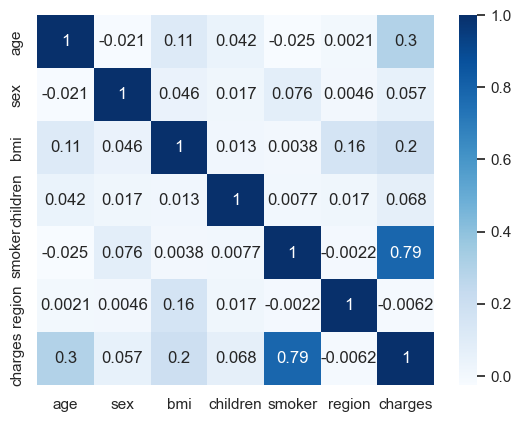

In [150]:
# correlation plot
sns.heatmap(correlations, cmap = 'Blues', annot= True)

Looks like there are correlation between smoking and medical expense. Lets look closer on it


From the correlation map, there are strong correlation between smokers and insurance charge(0.79), followed by age(0.3) and bmi(0.2) sligtly correlated. There are slightly to non correlation from sex, childeren, region to charges.

Now, Comparing insurance charges between regions:

<Axes: ylabel='region'>

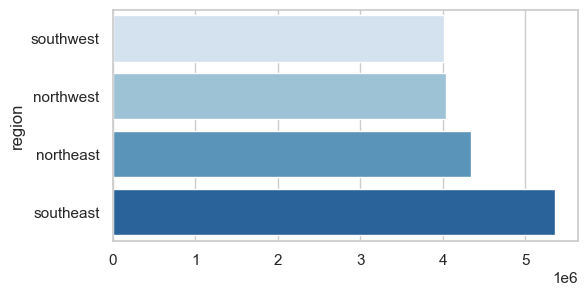

In [152]:
charges = df['charges'].groupby(df.region).sum().sort_values(ascending=True)
f, ax = plt.subplots(1, 1, figsize=(6, 3))
sns.barplot(x=charges.head().values, y=charges.head().index, palette='Blues', ax=ax)

So overall the highest medical charges are in the Southeast and the lowest are in the Southwest. Taking into account certain factors (sex, smoking, having children) let's see how it changes by region

Given that the Southeast experiences the highest medical charges, while the Southwest sees the lowest, it is important to analyze how these costs are influenced by various factors, such as sex, smoking status, and number of children, across different regions.

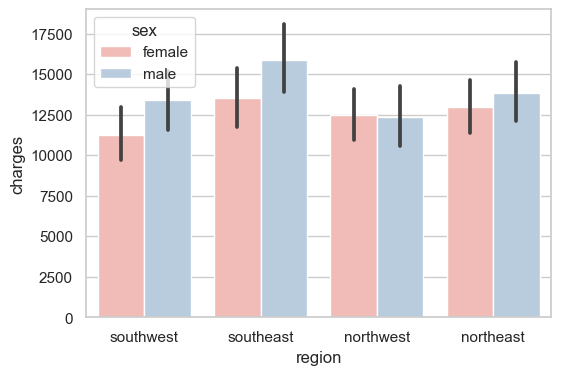

In [153]:
f, ax = plt.subplots(1, 1, figsize=(6, 4))
ax = sns.barplot(x='region', y='charges', hue='sex', data=df, palette='Pastel1')

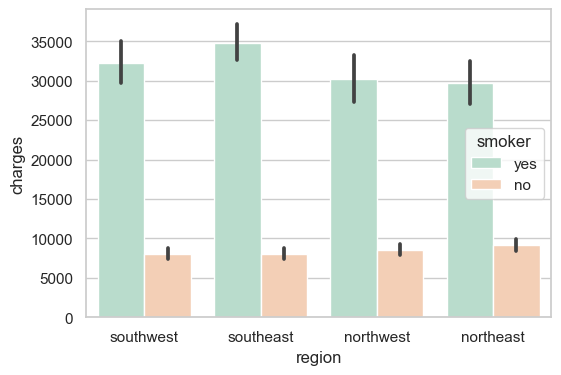

In [154]:
f, ax = plt.subplots(1,1, figsize=(6,4))
ax = sns.barplot(x = 'region', y = 'charges',
                 hue='smoker', data=df, palette='Pastel2')

As we can see from these barplots the highest charges due to smoking are still in the Southeast but the lowest are in the Northeast. People in the Southwest generally smoke more than people in the Northeast, but people in the Northeast have higher charges by gender than in the Southwest and Northwest overall.

Now let's analyze the medical charges by age, bmi and children according to the smoking factor

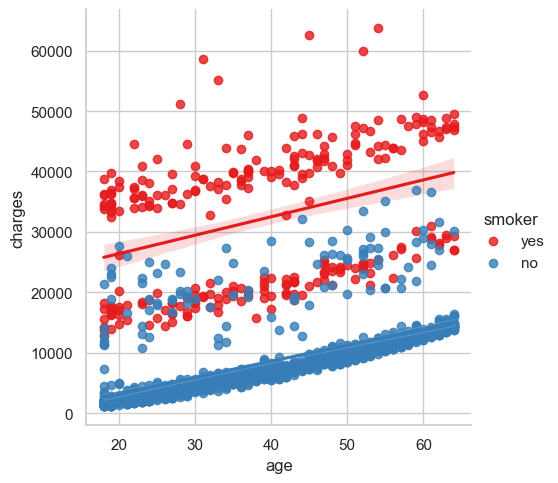

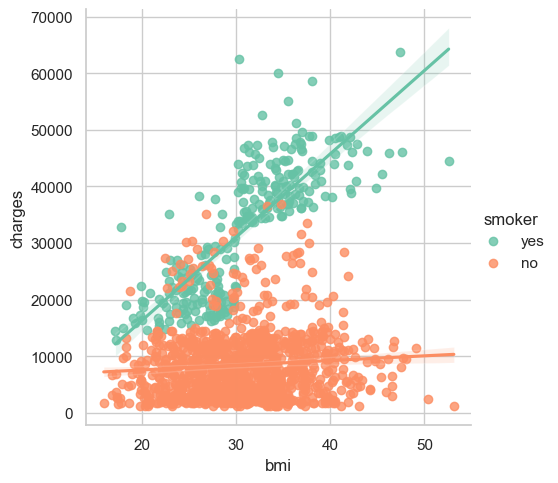

In [155]:
ax = sns.lmplot(x = 'age', y = 'charges', data=df, hue='smoker', palette='Set1')
ax = sns.lmplot(x = 'bmi', y = 'charges', data=df, hue='smoker', palette='Set2')

Although medical costs generally increase with age, BMI, and the number of children, smoking has the most significant impact on escalating these expenses.

***Linear regression***

In [156]:
#Linear regression
x = df_encoded.drop(['charges'], axis = 1)
y = df_encoded['charges']
#Training linear regression model
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=222)
Lr = LinearRegression()
Lr.fit(x_train, y_train)
print(Lr.intercept_)
print(Lr.coef_)
print(Lr.score(x_test, y_test))




-10677.267884367824
[  249.40848959  -132.94057836   303.85471211   513.78636413
 23095.53071183  -244.15148539]
0.799986170742685
Mean Squared Error: 34481992.51020934
Root Mean Squared Error: 5872.136962827872


In [166]:
#Evaluating the performance of the model
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)

Mean Squared Error: 268470854.56206095
Root Mean Squared Error: 16385.0802427715


The result we got is good enough, but we can try to improve it a bit by reducing unimportant features later

***Polynominal regression***

In [167]:
x = df_encoded.drop(['charges', 'sex', 'region'], axis = 1)
y = df_encoded.charges
pol = PolynomialFeatures (degree = 2)
x_pol = pol.fit_transform(x)
x_train, x_test, y_train, y_test = holdout(x_pol, y, test_size=0.2, random_state=0)
Pr = LinearRegression()
Pr.fit(x_train, y_train)
y_train_pred = Pr.predict(x_train)
y_test_pred = Pr.predict(x_test)


print(Pr.intercept_)
print(Pr.coef_)
print(Pr.score(x_test, y_test))


-5325.8817052527975
[ 0.00000000e+00 -4.01606591e+01  5.23702019e+02  8.52025026e+02
 -9.52698471e+03  3.04430186e+00  1.84508369e+00  6.01720286e+00
  4.20849790e+00 -9.38983382e+00  3.81612289e+00  1.40840670e+03
 -1.45982790e+02 -4.46151855e+02 -9.52698471e+03]
0.8812595703345231


In [168]:
##Evaluating the performance of the algorithm
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_test_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_test_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_test_pred)))

Mean Absolute Error: 2824.4950454776463
Mean Squared Error: 18895160.09878035
Root Mean Squared Error: 4346.856346692441


In [169]:
##Predicting the charges
y_test_pred = Pr.predict(x_test)
##Comparing the actual output values with the predicted values
data = pd.DataFrame({'Actual': y_test, 'Predicted': y_test_pred})
data

,Actual,Predicted
578,9724.53000,12101.156323
610,8547.69130,10440.782266
569,45702.02235,48541.022951
1034,12950.07120,14140.067522
198,9644.25250,8636.235727
...,...,...
1084,15019.76005,16712.196281
726,6664.68595,8654.565461
1132,20709.02034,12372.050609
725,40932.42950,41465.617268


Smoking is the greatest factor that affects medical insurance charges, followed by bmi and age. Polynomial Regression turned out to be better Linear Regression model

**Conclusion:** The analysis reveals that smoking is the most significant predictor of health insurance charges, exerting a profound influence on the cost of premiums. Smokers face considerably higher charges, reflecting the increased health risks and potential costs associated with smoking-related conditions. Following smoking, Body Mass Index (BMI) emerges as the second most impactful factor. Individuals with higher BMI levels incur greater insurance costs, likely due to the correlation between obesity and various chronic diseases that require frequent medical attention. Age also plays a critical role, with older individuals experiencing higher insurance charges, which can be attributed to the natural increase in health-related issues as one ages.

This analysis underscores the importance of lifestyle choices and demographic factors in determining health insurance costs. It highlights the potential financial benefits of smoking cessation and maintaining a healthy weight. As policymakers and healthcare providers strive to manage the escalating costs of healthcare, these findings can contribute to targeted interventions aimed at reducing smoking rates and encouraging healthy living, ultimately influencing insurance pricing strategies and promoting public health.